# Multi‑Agent Simulation Analysis – Living & Inert Agents with Basemap

This notebook analyses both **LivingAgent (mosquitoes)** and **InertAgent (water tanks)** from the merged snapshot CSV.
Spatial plots are displayed on top of a study area basemap (shapefile or GeoPackage).

## Configuration

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr
from scipy.signal import correlate, correlation_lags
import os
import warnings
warnings.filterwarnings('ignore')

# ========== CONFIGURATION ==========
INPUT_FILE = "/home/void/Documents/codes/monadvsim/results/merged_snapshots_20260415_163229.csv"   # adjust to your file
STUDY_AREA_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/dire_dawa/dire_dawa.shp"  # shapefile or .gpkg
OUTPUT_DIR = "analysis_output"
TICKS_PER_DAY = 96
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ========== LOAD STUDY AREA BASEMAP ==========
if os.path.exists(STUDY_AREA_FILE):
    study_area = gpd.read_file(STUDY_AREA_FILE)
    # Ensure CRS is WGS84 (EPSG:4326) for plotting with lon/lat
    if study_area.crs is None or study_area.crs.to_epsg() != 4326:
        study_area = study_area.to_crs("EPSG:4326")
    print(f"Loaded study area basemap: {STUDY_AREA_FILE}")
    print(f"Bounds: {study_area.total_bounds}")
else:
    print(f"Study area file not found: {STUDY_AREA_FILE}. Spatial plots will be without basemap.")
    study_area = None

# ========== LOAD DATA ==========
df = pd.read_csv(INPUT_FILE)
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Check required columns
required_living = ['AgentType', 'TickCount', 'Stage', 'X', 'Y', 't2m', 'tp']
required_inert = ['AgentType', 'TickCount', 'EggCount', 'LarvaCount', 'waterVolume', 'X', 'Y']
for col in required_living:
    if col not in df.columns:
        raise KeyError(f"Missing column '{col}' in CSV")
for col in required_inert:
    if col not in df.columns:
        print(f"Warning: column '{col}' missing, some inert analyses will be skipped")

# Split agent types
living = df[df['AgentType'] == 'LivingAgent'].copy()
inert = df[df['AgentType'] == 'InertAgent'].copy() if 'AgentType' in df.columns else pd.DataFrame()

print(f"\nLivingAgent records: {len(living)}")
print(f"InertAgent records: {len(inert)}")
print(f"Tick range: {living['TickCount'].min()} – {living['TickCount'].max()}")

Loaded study area basemap: /home/void/Documents/codes/monadvsim/prepared_data/dire_dawa/dire_dawa.shp
Bounds: [41.72802774  9.47148374 42.3397728   9.78374168]
Total rows: 719722
Columns: ['TickCount', 'AgentID', 'Layer', 'AgentType', 'X', 'Y', 'Alive', 'Age', 'Stage', 'Energy', 'Gravid', 'EggCount', 'LarvaCount', 'waterVolume', 'Resting', 'RestingDuration', 'TimeWithoutRest', 'Elevation', 'Buildings', 'Population', 't2m', 'tp']

LivingAgent records: 480472
InertAgent records: 239250
Tick range: 100 – 400


## 1. Pre‑processing & Quality Control

In [31]:
# Check for missing ticks
all_ticks = np.arange(living['TickCount'].min(), living['TickCount'].max()+1, 1)
present_ticks = living['TickCount'].unique()
missing_ticks = set(all_ticks) - set(present_ticks)
if missing_ticks:
    print(f"Warning: Missing ticks: {sorted(missing_ticks)[:10]}...")
else:
    print("All ticks present.")

# Impute missing environmental values? (optional – here we drop rows with NaN in t2m)
before = len(living)
living = living.dropna(subset=['t2m', 'tp'])
print(f"Dropped {before - len(living)} rows due to missing t2m/tp")

# Add day column
living['Day'] = living['TickCount'] / TICKS_PER_DAY
if not inert.empty:
    inert['Day'] = inert['TickCount'] / TICKS_PER_DAY

Dropped 0 rows due to missing t2m/tp


## 2. LivingAgent – Population Dynamics

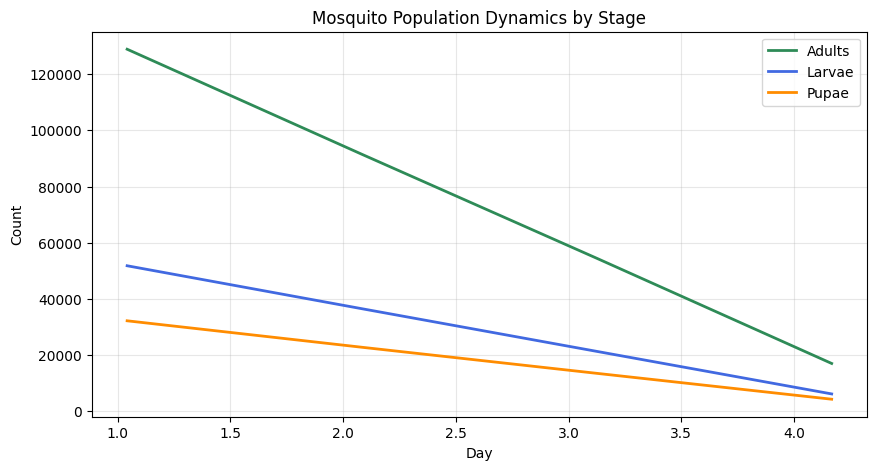

In [32]:
daily_adults = living[living['Stage']=='ADULT'].groupby('Day').size()
daily_larvae = living[living['Stage']=='LARVA'].groupby('Day').size()
daily_pupae = living[living['Stage']=='PUPA'].groupby('Day').size()

plt.figure(figsize=(10,5))
plt.plot(daily_adults.index, daily_adults.values, label='Adults', color=STAGE_COLORS['ADULT'], linewidth=2)
plt.plot(daily_larvae.index, daily_larvae.values, label='Larvae', color=STAGE_COLORS['LARVA'], linewidth=2)
plt.plot(daily_pupae.index, daily_pupae.values, label='Pupae', color=STAGE_COLORS['PUPA'], linewidth=2)
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Mosquito Population Dynamics by Stage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/mosquito_dynamics.png', dpi=300)
plt.show()

## 3. InertAgent – Water Tank Summary
Average water volume, egg count, larval count over time.

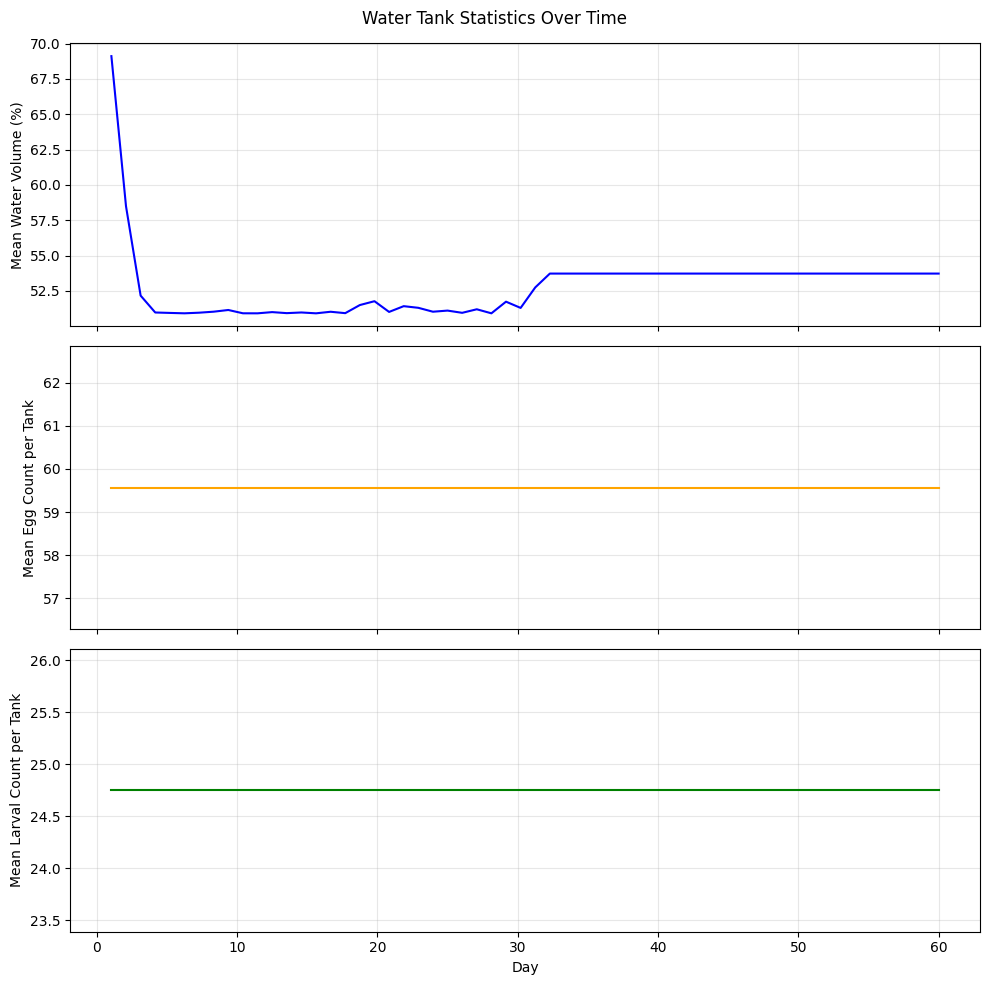

In [33]:
if not inert.empty:
    daily_tank_stats = inert.groupby('Day').agg({
        'waterVolume': 'mean',
        'EggCount': 'mean',
        'LarvaCount': 'mean'
    }).reset_index()

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    axes[0].plot(daily_tank_stats['Day'], daily_tank_stats['waterVolume'], color='blue')
    axes[0].set_ylabel('Mean Water Volume (%)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(daily_tank_stats['Day'], daily_tank_stats['EggCount'], color='orange')
    axes[1].set_ylabel('Mean Egg Count per Tank')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(daily_tank_stats['Day'], daily_tank_stats['LarvaCount'], color='green')
    axes[2].set_ylabel('Mean Larval Count per Tank')
    axes[2].set_xlabel('Day')
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Water Tank Statistics Over Time')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/tank_stats.png', dpi=300)
    plt.show()
else:
    print("No InertAgent data – skipping tank analysis.")

## 4. Environmental Correlation
Temperature and precipitation influence both mosquito populations and tank water dynamics.

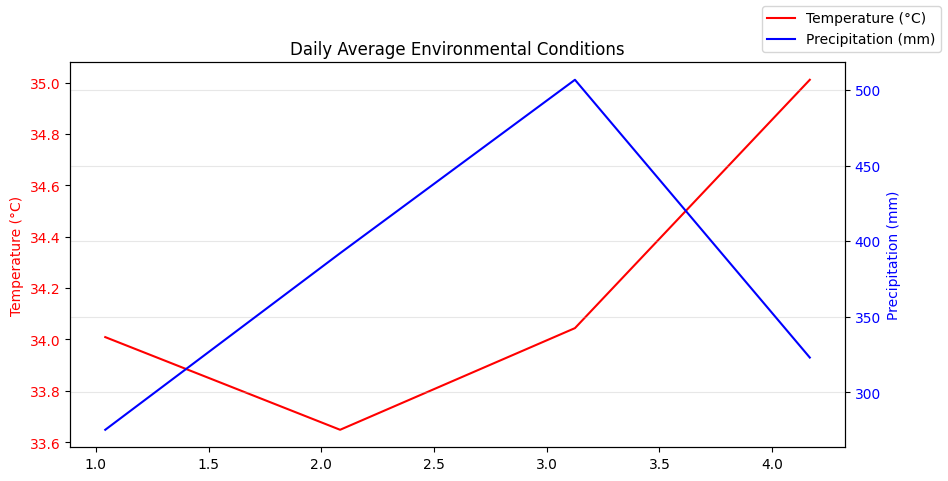

Correlation adult count vs temperature: r=-0.753 (p=2.473e-01)
Correlation adult count vs precipitation: r=-0.331 (p=6.695e-01)


In [34]:
daily_env = living.groupby('Day')[['t2m', 'tp']].mean()

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(daily_env.index, daily_env['t2m'], color='red', label='Temperature (°C)')
ax1.set_ylabel('Temperature (°C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(daily_env.index, daily_env['tp']*1000, color='blue', label='Precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Daily Average Environmental Conditions')
plt.xlabel('Day')
plt.grid(True, alpha=0.3)
fig.legend(loc='upper right')
plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300)
plt.show()

adult_series = daily_adults.reindex(daily_env.index).fillna(0)
corr_temp, p_temp = pearsonr(adult_series, daily_env['t2m'])
corr_precip, p_precip = pearsonr(adult_series, daily_env['tp']*1000)
print(f"Correlation adult count vs temperature: r={corr_temp:.3f} (p={p_temp:.3e})")
print(f"Correlation adult count vs precipitation: r={corr_precip:.3f} (p={p_precip:.3e})")

## 5. Temporal Autocorrelation & Cross‑correlation

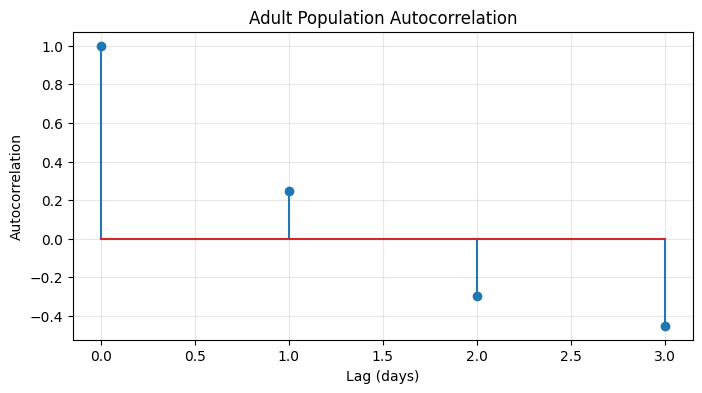

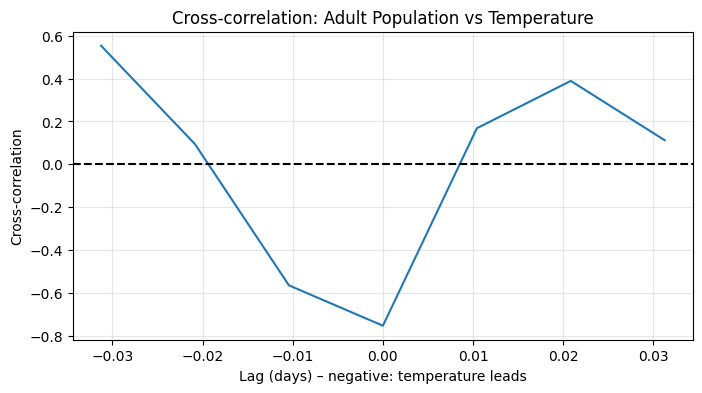

In [35]:
adult_vals = adult_series.values
lags = correlation_lags(len(adult_vals), len(adult_vals))
acf = correlate(adult_vals - adult_vals.mean(), adult_vals - adult_vals.mean(), mode='full')
acf = acf / acf[len(acf)//2]

plt.figure(figsize=(8,4))
plt.stem(lags[len(lags)//2: len(lags)//2+50], acf[len(acf)//2: len(acf)//2+50])
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.title('Adult Population Autocorrelation')
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/autocorrelation.png', dpi=300)
plt.show()

temp_vals = daily_env['t2m'].values
ccf = correlate(adult_vals - adult_vals.mean(), temp_vals - temp_vals.mean(), mode='full')
ccf = ccf / (len(adult_vals) * adult_vals.std() * temp_vals.std())
lag_days = lags / TICKS_PER_DAY

plt.figure(figsize=(8,4))
plt.plot(lag_days, ccf)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Lag (days) – negative: temperature leads')
plt.ylabel('Cross‑correlation')
plt.title('Cross‑correlation: Adult Population vs Temperature')
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/crosscorrelation.png', dpi=300)
plt.show()

## 6. Spatial Analysis with Basemap

All spatial plots now overlay the study area boundary.

### 6.1 Adult mosquito density heatmap + tank locations

In [ ]:
ticks = sorted(living['TickCount'].unique())
selected = [ticks[0], ticks[len(ticks)//2], ticks[-1]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, tick in zip(axes, selected):
    adults = living[(living['TickCount']==tick) & (living['Stage']=='ADULT')]
    tanks = inert[inert['TickCount']==tick] if not inert.empty else pd.DataFrame()
    if tanks.empty and not inert.empty:
        tanks = inert[inert['TickCount']==inert['TickCount'].min()]
    
    # Plot basemap first
    if study_area is not None:
        study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.5)
    
    # Heatmap of adult mosquitoes
    if len(adults) > 5:
        sns.kdeplot(data=adults, x='X', y='Y', fill=True, cmap='viridis', alpha=0.6, ax=ax)
    # Tank locations
    if not tanks.empty:
        ax.scatter(tanks['X'], tanks['Y'], s=10, marker='x', color='black', alpha=0.5, label='Tanks')
    # Adult positions
    ax.scatter(adults['X'], adults['Y'], s=5, color='green', alpha=0.3, label='Adults')
    ax.set_title(f'Tick {tick} (Day {tick/TICKS_PER_DAY:.1f})\nAdults: {len(adults)}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    if ax == axes[0]:
        ax.legend()

plt.suptitle('Spatial Distribution: Adult Mosquitoes vs Water Tanks')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/spatial_with_basemap.png', dpi=300)
plt.show()

### 6.2 Proximity analysis (adult to nearest tank) over time

In [ ]:
if not inert.empty:
    proximity = []
    for tick in ticks[::max(1, len(ticks)//50)]:
        adults = living[(living['TickCount']==tick) & (living['Stage']=='ADULT')]
        tanks = inert[inert['TickCount']==tick]
        if tanks.empty:
            tanks = inert[inert['TickCount']==inert['TickCount'].min()]
        if len(adults)>0 and len(tanks)>0:
            tree = cKDTree(tanks[['X','Y']].values)
            dists, _ = tree.query(adults[['X','Y']].values)
            proximity.append({'Tick': tick, 'Day': tick/TICKS_PER_DAY, 'MeanDist_deg': np.mean(dists), 'MedianDist_deg': np.median(dists)})

    prox_df = pd.DataFrame(proximity)
    plt.figure(figsize=(8,5))
    plt.plot(prox_df['Day'], prox_df['MeanDist_deg']*111, marker='o', linestyle='-', label='Mean distance (km)')
    plt.fill_between(prox_df['Day'], prox_df['MeanDist_deg']*111 - prox_df['MedianDist_deg']*111, 
                     prox_df['MeanDist_deg']*111 + prox_df['MedianDist_deg']*111, alpha=0.2)
    plt.xlabel('Day')
    plt.ylabel('Distance to nearest tank (km)')
    plt.title('Adult Mosquito Proximity to Breeding Sites')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(f'{OUTPUT_DIR}/proximity.png', dpi=300)
    plt.show()
else:
    print("No tank data – skipping proximity analysis.")

### 6.3 Local Indicators of Spatial Association (LISA) – hotspots

In [ ]:
def get_hotspots(adults, radius_deg=0.001):
    if len(adults) < 2:
        return np.zeros(len(adults))
    tree = cKDTree(adults[['X','Y']].values)
    neighbors = tree.query_ball_tree(tree, radius_deg)
    return np.array([len(n) for n in neighbors])

last_tick = ticks[-1]
adults_last = living[(living['TickCount']==last_tick) & (living['Stage']=='ADULT')]
if len(adults_last) > 0:
    hotspots = get_hotspots(adults_last, radius_deg=0.0005)
    plt.figure(figsize=(8,6))
    if study_area is not None:
        study_area.boundary.plot(ax=plt.gca(), color='black', linewidth=1, alpha=0.5)
    sc = plt.scatter(adults_last['X'], adults_last['Y'], c=hotspots, cmap='hot', s=10, alpha=0.7)
    plt.colorbar(sc, label='Number of adults within 55m')
    plt.title(f'Adult Hotspots (Tick {last_tick}, Day {last_tick/TICKS_PER_DAY:.1f})')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/hotspots_with_basemap.png', dpi=300)
    plt.show()

## 7. Tank Occupancy Heatmap (Eggs + Larvae per Tank)

In [ ]:
if not inert.empty:
    last_tick_inert = inert['TickCount'].max()
    tanks_last = inert[inert['TickCount']==last_tick_inert].copy()
    tanks_last['Immature'] = tanks_last['EggCount'] + tanks_last['LarvaCount']

    plt.figure(figsize=(10,8))
    if study_area is not None:
        study_area.boundary.plot(ax=plt.gca(), color='black', linewidth=1, alpha=0.5)
    sc = plt.scatter(tanks_last['X'], tanks_last['Y'], c=tanks_last['Immature'], cmap='plasma', s=20, alpha=0.7)
    plt.colorbar(sc, label='Eggs + Larvae per tank')
    plt.title(f'Breeding Site Load (Tick {last_tick_inert}, Day {last_tick_inert/TICKS_PER_DAY:.1f})')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/tank_load_with_basemap.png', dpi=300)
    plt.show()
else:
    print("No tank data – skipping occupancy heatmap.")

## 8. Validation: Compare Observed Growth with Metzler Matrix Prediction

In [ ]:
def metzler_lambda_max(T_C, livestock_density, params):
    a, b, Tmax, c = params['fecundity_a'], params['fecundity_b'], params['fecundity_Tmax'], params['fecundity_c']
    term1 = a * np.exp(b * T_C)
    term2 = np.exp(b * Tmax - ((Tmax - T_C)/c)**2)
    F = max(0, term1 - term2)
    
    dE = max(0, params['egg_dev_a']*T_C**2 + params['egg_dev_b']*T_C + params['egg_dev_c'])
    dL = max(0, params['larva_dev_a']*T_C**2 + params['larva_dev_b']*T_C + params['larva_dev_c'])
    dP = max(0, params['pupa_dev_a']*T_C**2 + params['pupa_dev_b']*T_C + params['pupa_dev_c'])
    muA = max(0, params['adult_mort_a']*T_C**2 + params['adult_mort_b']*T_C + params['adult_mort_c'])
    
    SE = params['egg_survival_amp'] * np.exp(-0.5 * ((T_C - params['egg_survival_mean'])/params['egg_survival_sigma'])**2)
    SL = params['larva_survival_amp'] * np.exp(-0.5 * ((T_C - params['larva_survival_mean'])/params['larva_survival_sigma'])**2)
    SP = params['pupa_survival_amp'] * np.exp(-0.5 * ((T_C - params['pupa_survival_mean'])/params['pupa_survival_sigma'])**2)
    
    K = 1 + np.log1p(max(0, livestock_density))
    
    M = np.array([
        [-dE, 0, 0, F * K],
        [SE*dE, -dL, 0, 0],
        [0, SL*dL, -dP, 0],
        [0, 0, SP*dP, -muA]
    ])
    v = np.ones(4)
    for _ in range(50):
        v = M @ v
        v = v / np.linalg.norm(v)
    lambda_max = (v @ (M @ v)) / (v @ v)
    return lambda_max

params = {
    'fecundity_a': 0.378, 'fecundity_b': 0.173, 'fecundity_Tmax': 40.0, 'fecundity_c': 2.97,
    'egg_dev_a': -0.0009, 'egg_dev_b': 0.048, 'egg_dev_c': -0.345,
    'larva_dev_a': -0.0007, 'larva_dev_b': 0.039, 'larva_dev_c': -0.32,
    'pupa_dev_a': -0.0005, 'pupa_dev_b': 0.026, 'pupa_dev_c': -0.2,
    'egg_survival_amp': 1.01, 'egg_survival_mean': 24.5, 'egg_survival_sigma': 4.8,
    'larva_survival_amp': 0.95, 'larva_survival_mean': 27.0, 'larva_survival_sigma': 3.5,
    'pupa_survival_amp': 0.93, 'pupa_survival_mean': 26.8, 'pupa_survival_sigma': 3.8,
    'adult_mort_a': -0.00065, 'adult_mort_b': 0.0364, 'adult_mort_c': -0.4882
}

daily_livestock = living.groupby('Day')['population'].mean() if 'population' in living.columns else pd.Series(0, index=daily_env.index)
lambda_vals = []
for day, row in daily_env.iterrows():
    T_C = row['t2m']
    liv = daily_livestock.get(day, 0)
    lam = metzler_lambda_max(T_C, liv, params)
    lambda_vals.append(lam)

adult_log = np.log(adult_series + 1)
obs_growth = np.diff(adult_log)
days_obs = adult_series.index[1:]
lambda_series = pd.Series(lambda_vals, index=daily_env.index)
aligned_lam = lambda_series.reindex(days_obs).values

plt.figure(figsize=(10,5))
plt.plot(days_obs, obs_growth, label='Observed daily log growth rate', alpha=0.7)
plt.plot(days_obs, aligned_lam, label='Predicted λmax (Metzler)', linestyle='--', color='red')
plt.xlabel('Day')
plt.ylabel('Rate (1/day)')
plt.title('Observed vs Predicted Population Growth Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/growth_validation.png', dpi=300)
plt.show()

## 9. Stage Duration Estimation

In [ ]:
larvae_vals = daily_larvae.reindex(daily_env.index).fillna(0).values
pupae_vals = daily_pupae.reindex(daily_env.index).fillna(0).values
adult_vals2 = adult_series.reindex(daily_env.index).fillna(0).values

ccf_lp = correlate(larvae_vals - larvae_vals.mean(), pupae_vals - pupae_vals.mean(), mode='full')
lag_lp = lags[np.argmax(ccf_lp)] / TICKS_PER_DAY
print(f"Estimated larval duration: {lag_lp:.2f} days")

ccf_pa = correlate(pupae_vals - pupae_vals.mean(), adult_vals2 - adult_vals2.mean(), mode='full')
lag_pa = lags[np.argmax(ccf_pa)] / TICKS_PER_DAY
print(f"Estimated pupal duration: {lag_pa:.2f} days")

## 10. Export Tidy Data

In [ ]:
daily_living_sum = living.groupby('Day').agg(
    AdultCount=('Stage', lambda x: (x=='ADULT').sum()),
    LarvaCount=('Stage', lambda x: (x=='LARVA').sum()),
    PupaCount=('Stage', lambda x: (x=='PUPA').sum()),
    MeanTemp=('t2m', 'mean'),
    MeanPrecip=('tp', 'mean')
).reset_index()

if not inert.empty:
    daily_inert_sum = inert.groupby('Day').agg(
        TankCount=('AgentID', 'nunique'),
        MeanWaterVolume=('waterVolume', 'mean'),
        TotalEggs=('EggCount', 'sum'),
        TotalLarvae=('LarvaCount', 'sum')
    ).reset_index()
    daily_summary = pd.merge(daily_living_sum, daily_inert_sum, on='Day', how='outer')
else:
    daily_summary = daily_living_sum

daily_summary.to_csv(f'{OUTPUT_DIR}/daily_summary.csv', index=False)

living_sample = living.sample(min(1000, len(living)))
living_sample.to_csv(f'{OUTPUT_DIR}/living_sample.csv', index=False)

print(f"Summaries saved to {OUTPUT_DIR}/")
print("Files: daily_summary.csv, living_sample.csv")